###**1. Importing libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###**2. Loading the dataset**

In [ ]:
insurance = pd.read_csv('/content/insurance.csv')
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


###**3. Dataset description**

In [ ]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


###**4. Data Cleaning**

In [ ]:
#4.1 Dataset shape
insurance.shape

(1338, 7)

The Dataset has 1338 Rows and seven columns.

In [ ]:
#4.2 Checking the Data Types
insurance.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


The columns have the correct datatypes

In [ ]:
#4.3 Checking for missing values
insurance.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


The dataset has no missing values

In [ ]:
#4.4 Checking for duplicates
insurance.duplicated().sum()

np.int64(1)

In [ ]:
#Removing the duplicated value
insurance = insurance.drop_duplicates()

In [ ]:
#4.5 Descriptive Statistics
insurance.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


It highlights an adult population with a mean age of roughly 39 years old, an average BMI of 30.66 (which falls into the obese range), an average of about one child per person, and annual medical charges that average $13,270.42 but vary drastically from 1,121.87 up to 63,770.43.

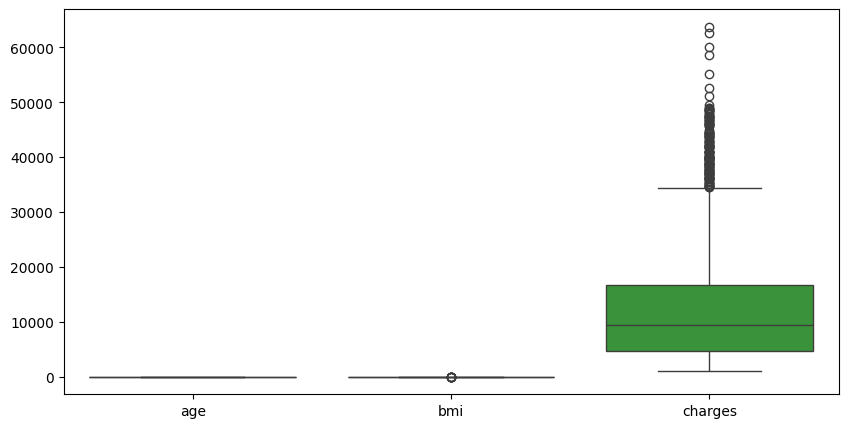

In [ ]:
#4.6 Checking outliers
plt.figure(figsize=(10,5))
sns.boxplot(data=insurance[['age','bmi','charges']])
plt.show()


You can't see if age or bmi have any outliers because they are completely flattened at the bottom. However, for charges, you can clearly see a long string of dot outliers above $35,000, showing that a small group of people have exceptionally high medical bills compared to everyone else.

###**5. Exploratory Data Analysis (EDA)**

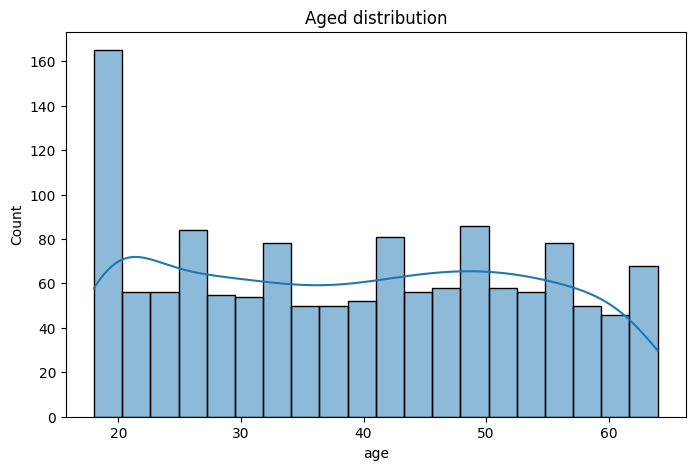

In [ ]:
#5.1 Distribution of Age
plt.figure(figsize=(8,5))
sns.histplot(insurance['age'],bins=20,kde=True)
plt.title('Aged distribution')
plt.show()

There is  a huge number of young people around 18 to 20 years old. After that spike, the rest of the age groups (from 21 to 64) are spread out very evenly, with roughly the same number of people in each age bracket.

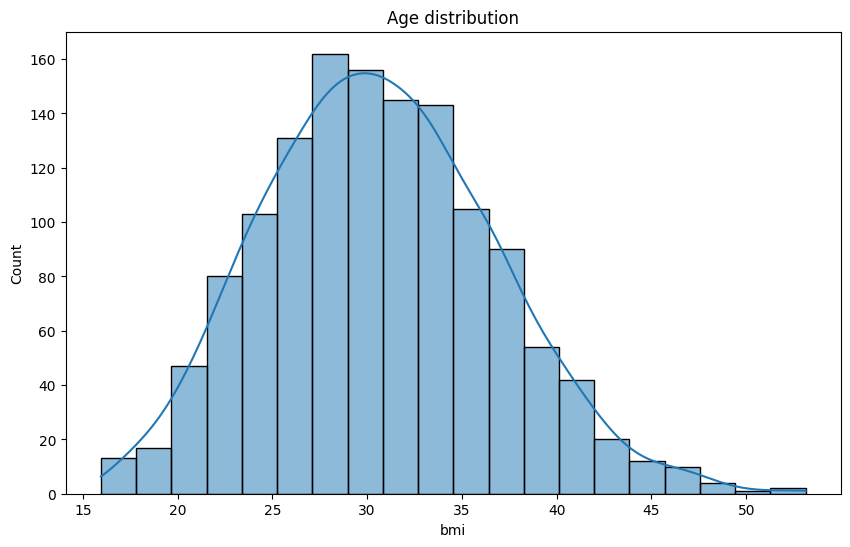

In [ ]:
#5.2 Distribution of BMI
plt.figure(figsize=(10,6))
sns.histplot(insurance['bmi'],bins=20,kde=True)
plt.title('Age distribution')
plt.show()

 BMI follows a normal distribution. Most people  have a BMI clustered right in the middle around 30, while very few people have extremely low BMIs (under 20) or extremely high BMIs (over 45).

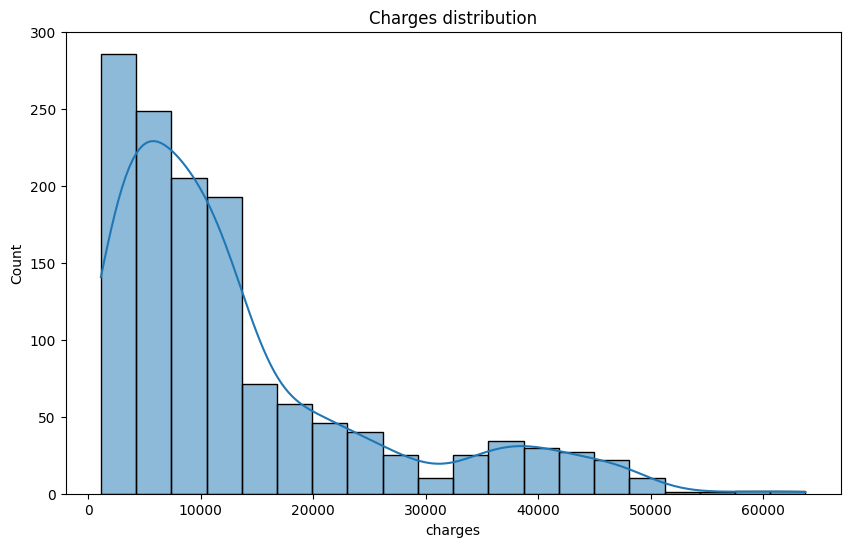

In [ ]:
#5.3 Distribution of Charges
plt.figure(figsize=(10,6))
sns.histplot(insurance['charges'],bins=20,kde=True)
plt.title('Charges distribution')
plt.show()

Medical charges are heavily right-skewed, meaning the vast majority of people have lower costs concentrated between 1,100 and 15,000. There is also a interesting smaller hump further to the right between 35,000 and 50,000, showing a specific smaller group of people who face much higher medical bills.

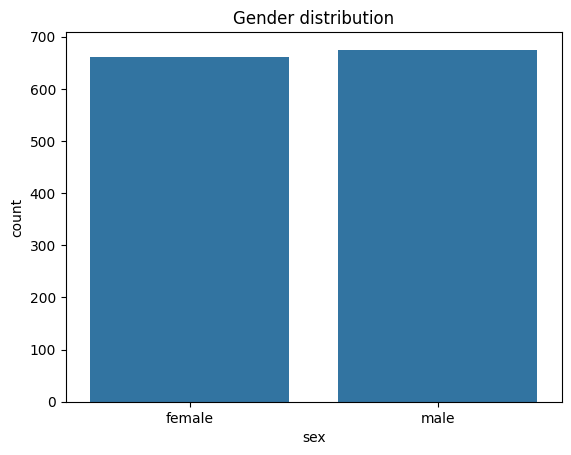

In [ ]:
#5.4 Gender Distribution
sns.countplot(x='sex', data=insurance)
plt.title('Gender distribution')
plt.show()

It is nearly perfectly balanced between genders. There is an almost equal number of males and females, with both groups hovering just under 700 individuals.

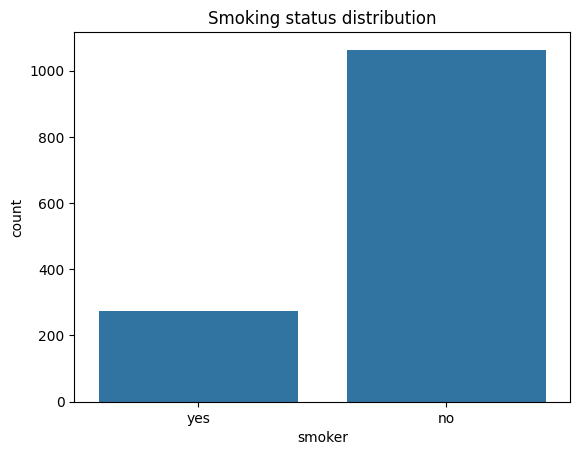

In [ ]:
#5.5 Smoking Status
sns.countplot(x='smoker', data=insurance)
plt.title('Smoking status distribution')
plt.show()

The vast majority of people  do not smoke. Non-smokers make up a large crowd of over 1,000 individuals, while smokers represent a much smaller group of around 270 people.

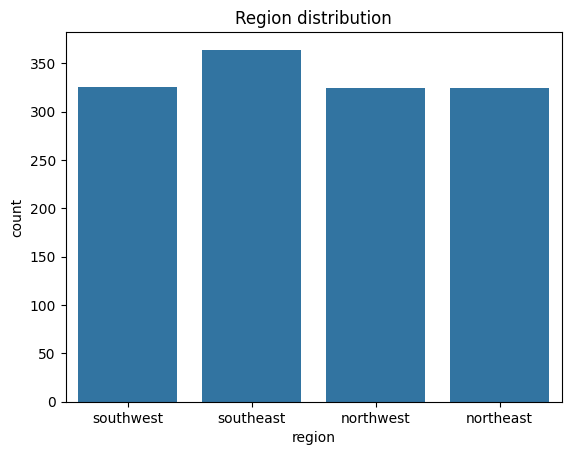

In [ ]:
#5.6 Region Distribution
sns.countplot(x='region', data = insurance)
plt.title('Region distribution')
plt.show()

The southwest, northwest, and northeast regions have an identical number of people (325 each), while the southeast region has a slightly higher count of around 364 people.

**Relationship Analysis**

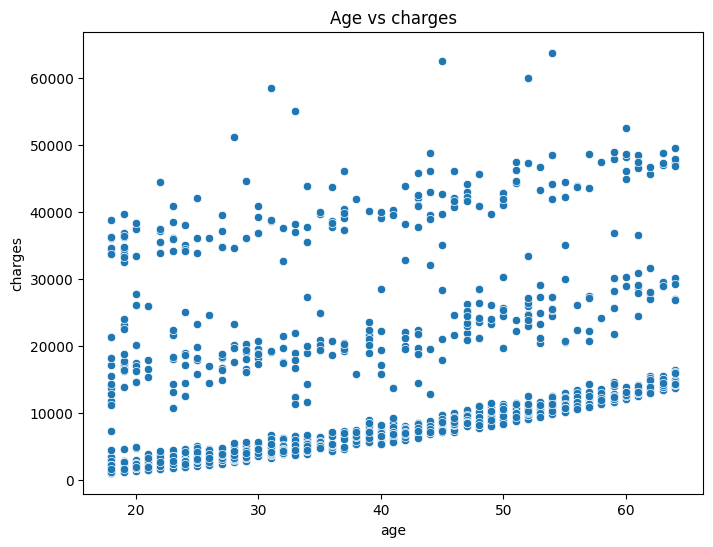

In [ ]:
#Age vs Charges
plt.figure(figsize=(8,6))
sns.scatterplot(x='age',y='charges',data=insurance)
plt.title('Age vs charges')
plt.show()

Medical bills generally increase with age, they are split into three separate, upward-sloping tiers. The bottom tier shows a steady, low-cost baseline for most people, while the middle and top tiers highlight specific groups facing much higher expenses as they grow older.

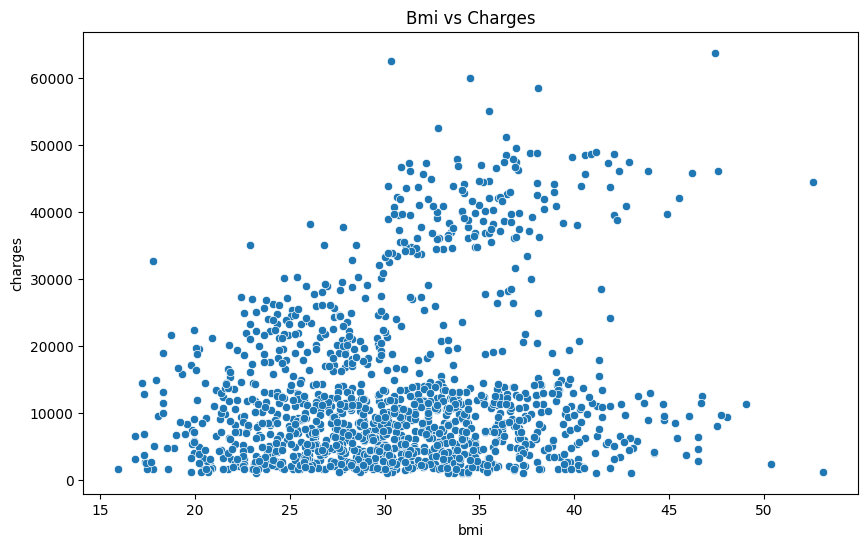

In [ ]:
#BMI vs Charges
plt.figure(figsize=(10,6))
sns.scatterplot(x='bmi',y='charges',data=insurance)
plt.title('Bmi vs Charges')
plt.show()

People with a BMI under 30, medical charges stay low and clustered under 15,000 regardless of their weight. However, once BMI crosses the 30 mark, the data splits dramatically: one group stays low, while a massive second group jumps up to face extreme charges between 30,000 and 60,000 (which is highly likely driven by whether they smoke or not).

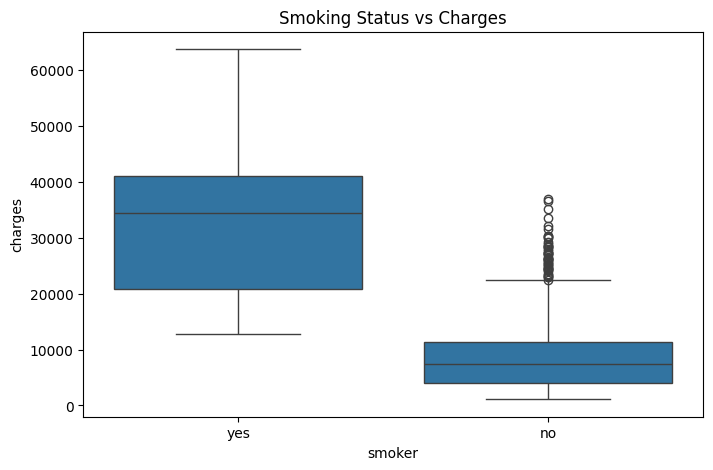

In [ ]:
#Smoker vs Charges
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges', data=insurance)
plt.title('Smoking Status vs Charges')
plt.show()


Smoking status is the main driver behind the high medical costs, showing that smokers have vastly higher charges with a median near 35,000. In contrast, non-smokers typically have much lower charges, usually staying well under 15,000, with any costs above 22,000 showing up as outliers.

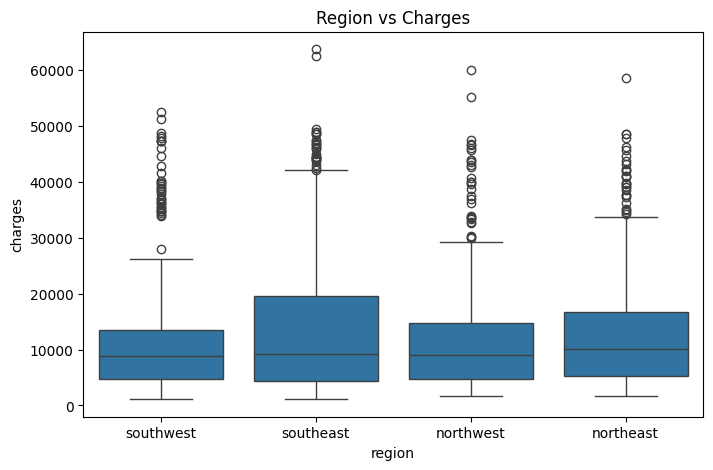

In [ ]:
#Region vs Charges
plt.figure(figsize=(8,5))
sns.boxplot(x='region', y='charges', data=insurance)
plt.title('Region vs Charges')
plt.show()

Medical charges are remarkably similar across all four regions, sitting just under 10,000. However, the southeast region has a noticeably wider cost spread and higher upper limit, while every single region contains a heavy trail of high-cost outliers reaching up past 50,000.

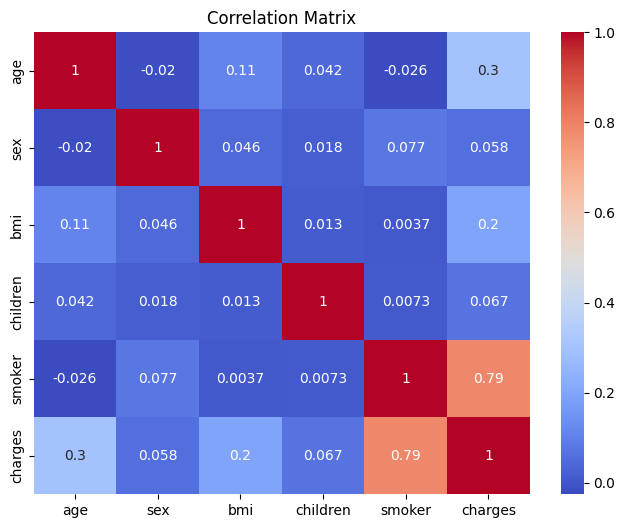

In [ ]:
#Correlation Analysis
df_numeric = insurance.copy()

df_numeric['sex'] = df_numeric['sex'].map({'male':1,'female':0})
df_numeric['smoker'] = df_numeric['smoker'].map({'yes':1,'no':0})

corr = df_numeric.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

This heatmap shows how different factors relate to medical costs, revealing that being a smoker has by far the strongest link to high charges with a very strong positive correlation of 0.79. Other traits like age (0.3) and BMI (0.2) show only weak links to higher bills, while gender and the number of children have almost no connection at all.

###**6. Answering Business Questions**

In [ ]:
#6.1  What is the average insurance charge?
avg_charge = insurance['charges'].mean()
print("The Avg_charge insurance charge is:",round(avg_charge,2))

The Avg_charge insurance charge is: 13279.12


In [ ]:
#6.2 Which age group contributes most to premium revenue?
insurance['age_group'] = pd.cut(insurance['age'],bins=(18,30,45,60,100),labels=['18-30','31-45','46-60','60+'])
revenue = insurance.groupby('age_group')['charges'].sum().sort_values(ascending=False)
revenue

/tmp/ipykernel_7367/1682892981.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue = insurance.groupby('age_group')['charges'].sum().sort_values(ascending=False)


,charges
age_group,
46-60,6.683466e+06
31-45,4.983098e+06
18-30,3.681925e+06
60+,1.916748e+06


46–60 bracket brings in the most money at roughly $6.68 million. This means middle-aged adults are the biggest source of revenue for the business, generating far more total income than the youngest or the very oldest groups.

In [ ]:
#6.3. What percentage of customers are smokers?
perc_smokers = (insurance['smoker'].value_counts(normalize=True)['yes']*100)
print(f"Percentage Smokers: {perc_smokers:.2f}%")

Percentage Smokers: 20.49%


In [ ]:
#6.4  How much more do smokers pay than non-smokers
insurance.groupby('smoker')['charges'].mean()

,charges
smoker,
no,8440.660307
yes,32050.231832


In [ ]:
smokers = insurance[insurance['smoker']=='yes']['charges'].mean()
non_smokers = insurance[insurance['smoker']=='no']['charges'].mean()
diffrence = smokers - non_smokers
print("Smoker Average:", round(smokers,2))
print("Non-Smoker Average:", round(non_smokers,2))
print("Difference:", round(diffrence,2))

Smoker Average: 32050.23
Non-Smoker Average: 8440.66
Difference: 23609.57


On average, smokers pay $23,609.57 more than non-smokers. This means a smoker's medical charges are nearly four times (about 3.8 times) as expensive as a non-smoker's.

In [ ]:
#6.5  Which region generates the highest insurance charges?
region_charges = insurance.groupby('region')['charges'].sum().sort_values(ascending=False)
region_charges

,charges
region,
southeast,5.363690e+06
northeast,4.343669e+06
northwest,4.034072e+06
southwest,4.012755e+06


The southeast region is the insurance company's largest cost driver, generating roughly $5.36 million in total bills. This spike means the company must focus its risk management and pricing strategies there, as the southeast suffers from a larger volume of high-cost cases compared to the other three regions.

In [17]:
#6.6 Does obesity significantly affect insurance costs?
insurance['BMI'] = pd.cut(insurance['bmi'],bins=[0,18.5,25,30,100], labels=['Underweight','Normal','Overweight','Obese'])
insurance.groupby('BMI')['charges'].mean()

/tmp/ipykernel_7364/2692465895.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  insurance.groupby('BMI')['charges'].mean()


,charges
BMI,
Underweight,8657.620652
Normal,10435.440719
Overweight,10997.803881
Obese,15580.700985


Obesity significantly increases insurance costs. The average medical charge for individuals classified as obese is $\$15,580.70$, which is approximately 49% higher than the charges for individuals with a normal BMI ($\$10,435.44$) and substantially higher than any other weight group.

In [18]:
#6.7. Does family size affect premiums?
family_charge=insurance.groupby('children')['charges'].mean()
print(round(family_charge,2))

children
0    12384.70
1    12731.17
2    15073.56
3    15355.32
4    13850.66
5     8786.04
Name: charges, dtype: float64


Insurance costs go up as families grow from 0 to 3 children, peaking at about $15,355. However, costs unexpectedly drop for larger families with 4 or 5 children, meaning premiums don't just automatically increase with every single child added.


In [21]:
#6.8 Which customer segment is highest risk?
insurance['age_group'] = pd.cut(insurance['age'],bins=(18,30,45,60,100),labels=['18-30','31-45','46-60','60+'])
risk_segment = insurance.groupby(['age_group','smoker'])['charges'].mean().sort_values(ascending=False)
print(risk_segment)

age_group  smoker
60+        yes       38929.615407
46-60      yes       36451.732069
31-45      yes       31707.164316
18-30      yes       27825.092529
60+        no        15366.613482
46-60      no        12188.334036
31-45      no         7246.170138
18-30      no         4716.295039
Name: charges, dtype: float64


/tmp/ipykernel_7364/3302113512.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_segment = insurance.groupby(['age_group','smoker'])['charges'].mean().sort_values(ascending=False)


The highest-risk customer segment is the 60+ age group who smoke, generating the highest average charges at $38,929.62. In fact, across all age brackets, smokers consistently pose a much higher financial risk than non-smokers, with even the youngest smokers (18–30) costing significantly more than the oldest non-smokers (60+).